<a href="https://colab.research.google.com/github/ipr2104/Advanced-Quant/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 2 Python Scripts

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

In [ ]:
df = pd.read_csv("./Paris_Tmax.csv", parse_dates= ["time"])
df = df.rename(columns= {"time": "DATE", "temperature_2m_max": "TMAX"})
df = df.dropna(subset= ["TMAX"]).sort_values("DATE").reset_index(drop= True)
df["Year"] = df["DATE"].dt.year
df["Month"] = df["DATE"].dt.month
df.head()

,DATE,TMAX,Year,Month
0,1950-01-01,5.203226,1950,1
1,1950-02-01,9.950000,1950,2
2,1950-03-01,11.322581,1950,3
3,1950-04-01,13.083333,1950,4
4,1950-05-01,18.735484,1950,5


In [ ]:
# Get montly mean Tmax
g = df.groupby(["Year", "Month"])["TMAX"]
monthly = g.mean().reset_index()
monthly

,Year,Month,TMAX
0,1950,1,5.203226
1,1950,2,9.950000
2,1950,3,11.322581
3,1950,4,13.083333
4,1950,5,18.735484
...,...,...,...
913,2026,2,11.910714
914,2026,3,14.003226
915,2026,4,18.980000
916,2026,5,21.435484


In [ ]:
# Add date to the montly dataframe
monthly["DATE"] = pd.to_datetime(
    dict(
        year = monthly["Year"],
        month = monthly["Month"],
        day = 1
    )
)

monthly

,Year,Month,TMAX,DATE
0,1950,1,5.203226,1950-01-01
1,1950,2,9.950000,1950-02-01
2,1950,3,11.322581,1950-03-01
3,1950,4,13.083333,1950-04-01
4,1950,5,18.735484,1950-05-01
...,...,...,...,...
913,2026,2,11.910714,2026-02-01
914,2026,3,14.003226,2026-03-01
915,2026,4,18.980000,2026-04-01
916,2026,5,21.435484,2026-05-01


In [ ]:
# Get the mean and variance
mean_tmax = monthly["TMAX"].mean()
variance_tmax = monthly["TMAX"].var()
std_tmax = monthly["TMAX"].std()

print(f"Mean: {mean_tmax:.2f}, Variance: {variance_tmax:.2f}, Std: {std_tmax:.2f}")

Mean: 14.96, Variance: 40.86, Std: 6.39


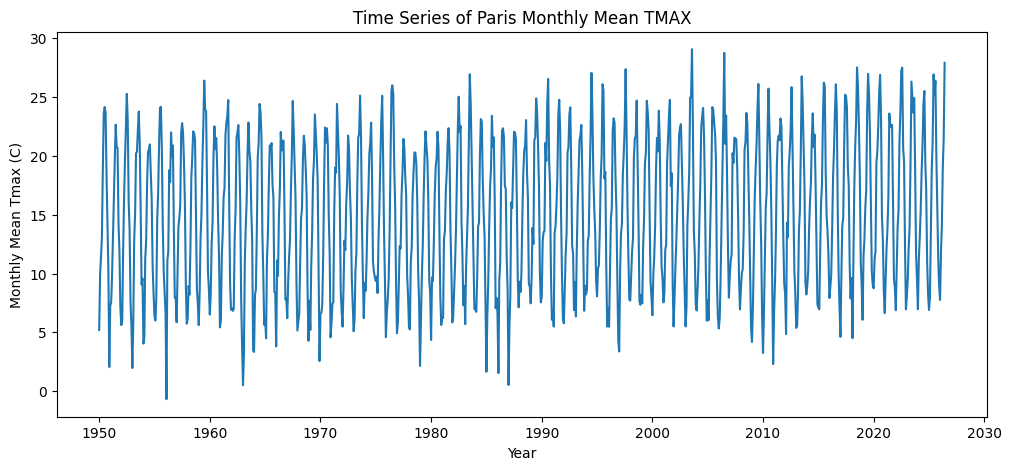

In [ ]:
# Time series plot
plt.figure(figsize = (12,5))
plt.plot(monthly["DATE"], monthly["TMAX"])
plt.xlabel("Year")
plt.ylabel("Monthly Mean Tmax (C)")
plt.title("Time Series of Paris Monthly Mean TMAX")
plt.show()


In [ ]:
min_row = monthly[monthly["TMAX"] == monthly["TMAX"].min()]
max_row = monthly[monthly["TMAX"] == monthly["TMAX"].max()]

print(min_row)
print(max_row)

    Year  Month      TMAX       DATE
73  1956      2 -0.689655 1956-02-01
     Year  Month       TMAX       DATE
643  2003      8  29.077419 2003-08-01


The Paris monthly mean Tmax series has a mean of 14.96C and a variance of 40.86C^2 with a standard devaition of 6.39C. The time series shows a strong annual cycle where Tmax peaks in the summer months  and bottoms out in the winter months. The highest monthly Tmax in the record is 29C in August 2003, while the lowest is -0.69C in February 1956. There is also a  warming trend which is evident by the upwards shift in temperatures from 1950 until now.

In [ ]:
# Climatological mean
clim = monthly.groupby("Month")["TMAX"].agg(["mean", "std", "count"])
clim

,mean,std,count
Month,,,
1,6.367491,2.018126,77
2,7.893710,2.448550,77
3,11.236028,1.830786,77
4,14.356147,1.863675,77
5,18.124298,1.732667,77
6,21.418442,2.030907,77
7,23.454499,2.031098,76
8,23.348557,1.990643,76
9,20.326404,1.848761,76


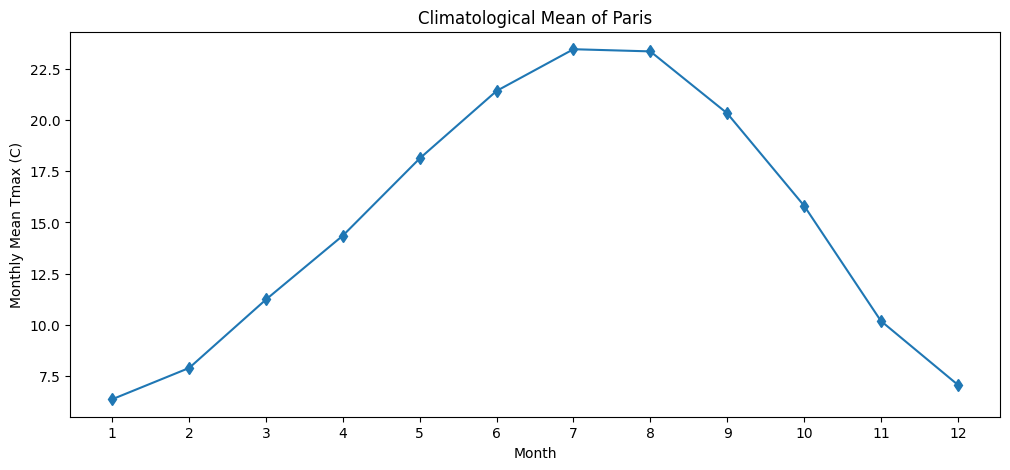

In [ ]:
# Plot climatological mean
month_label = np.arange(1,13)

plt.figure(figsize = (12,5))
plt.plot(month_label, clim["mean"], "d-")
plt.xlabel("Month")
plt.ylabel("Monthly Mean Tmax (C)")
plt.title("Climatological Mean of Paris")
plt.xticks(month_label)
plt.show()

In [ ]:
# 12 month centered running mean
x = monthly["TMAX"].values

t_step = 12
n = len(x)
out = np.full(n, np.nan)

h= t_step // 2

for i in range(h, n - h):
    w = x[i-h:i+h+1].copy()
    if t_step % 2 == 0:
        w[0] *= 0.5; w[-1] *= 0.5
    out[i] = w.sum() / t_step

running_trend = pd.Series(out, index=monthly.index)
monthly['running_trend'] = running_trend


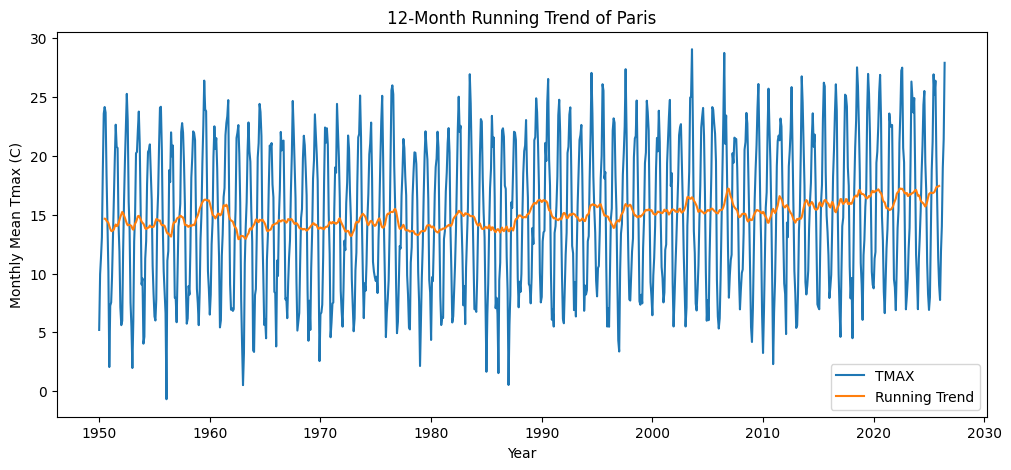

In [ ]:
# Plot running trend
plt.figure(figsize = (12,5))
plt.plot(monthly["DATE"], monthly["TMAX"], label = "TMAX")
plt.plot(monthly["DATE"], monthly["running_trend"], label = "Running Trend")

plt.xlabel("Year")
plt.ylabel("Monthly Mean Tmax (C)")
plt.title("12-Month Running Trend of Paris")
plt.legend()
plt.show()

In [ ]:
# Seasonal cycle from running mean
running_seasonal = (monthly["TMAX"] - monthly["running_trend"]).groupby(monthly["Month"]).mean()

# Add mean level back
running_seasonal = running_seasonal + monthly["running_trend"].mean()
running_seasonal

,0
Month,
1,6.377747
2,7.823787
3,11.206637
4,14.318443
5,18.077558
6,21.303687
7,23.455177
8,23.346764
9,20.322066


Text(0.5, 1.0, 'Seasonal Cycle of Paris from 12 Month Running Mean')

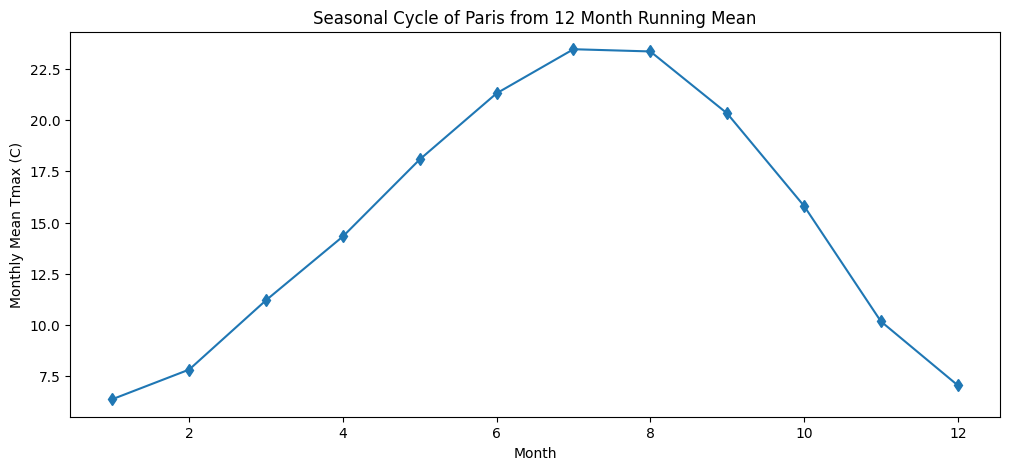

In [ ]:
# Plot seasonal cycle from runnng mean
plt.figure(figsize = (12,5))
plt.plot(month_label, running_seasonal, "d-")
plt.xlabel("Month")
plt.ylabel("Monthly Mean Tmax (C)")
plt.title("Seasonal Cycle of Paris from 12 Month Running Mean")


The climatological mean and the running mean are very similar but they differ a little in that the running mean removes the 12 month trend before averaging over month while the climatological mean does not. This allows some additional warming to remain in the climatological mean. The harmonic mean significantly differs from the other two because it finds the sine wave that best matches the data but in reality the seasonal cycle is not a perfect sine wave so this smoothed fit misses important aspects of the cycle.

In [ ]:
# Deseasonalize data
monthly["anom"] = monthly["TMAX"] - monthly["Month"].map(clim["mean"])
monthly

,Year,Month,TMAX,DATE,running_trend,anom
0,1950,1,5.203226,1950-01-01,NaN,-1.164265
1,1950,2,9.950000,1950-02-01,NaN,2.056290
2,1950,3,11.322581,1950-03-01,NaN,0.086552
3,1950,4,13.083333,1950-04-01,NaN,-1.272814
4,1950,5,18.735484,1950-05-01,NaN,0.611186
...,...,...,...,...,...,...
913,2026,2,11.910714,2026-02-01,NaN,4.017005
914,2026,3,14.003226,2026-03-01,NaN,2.767197
915,2026,4,18.980000,2026-04-01,NaN,4.623853
916,2026,5,21.435484,2026-05-01,NaN,3.311186


In [ ]:
# Mean and variance
mean_anom = monthly["anom"].mean()
variance_anom = monthly["anom"].var()
std_anom = monthly["anom"].std()

print(f"Mean of deseasonalized data: {mean_anom:.2f}")
print(f"Variance of deseasonalized data: {variance_anom:.2f}")
print(f"Std of deseasonalized data: {std_anom:.2f}")

Mean of deseasonalized data: 0.00
Variance of deseasonalized data: 3.63
Std of deseasonalized data: 1.90


Mean = 0 because I subtracted each month's average

Variance = 3.63 (1.90C std) meaning after subtracting climatological mean the anomalies have a variance of 3.63

1-3.63/40.86 = 0.911 = 91% variance from seasonal cycle

In [ ]:
# ACF
from statsmodels.tsa.stattools import acf

# Access 'anom' from the 'monthly' DataFrame and drop NaNs if any are present
acf(monthly["anom"].dropna(), nlags=5)[1:]

array([0.31073278, 0.22629921, 0.2178001 , 0.17127234, 0.16663959])

The ACF is positive and slowly decreases which means temperatures are persistent between months.

In [ ]:
# Fitting line

y = monthly["anom"].values
t = np.arange(len(y)) / 12 # years

res = stats.linregress(t, y)

n = len(y)

slope = res.slope

In [ ]:
# Residuals
resid = y - (res.intercept + slope * t)

# Lag 1 autocorrelation
r1 = acf(resid, nlags = 1, adjusted = False)[1]

In [ ]:
# Effective sample size
n_eff = n * (1-r1) / (1+r1)

# Adjusted SE
se_adj = res.stderr * np.sqrt((n-2) / (n_eff - 2))

# Adjusted 95% CI
tcrit_adj = stats.t.ppf(0.975, n_eff - 2)
ci_adj = (slope - tcrit_adj * se_adj, slope + tcrit_adj * se_adj)

# Per decade results
print(slope*10, ci_adj[0]*10, ci_adj[1]*10)

0.3182044629629116 0.25420715063567295 0.38220177529015026


Linear trend in deseasonalized data shows 0.32C of warming per decade with a 95% CI of 0.25-0.38C per decade.

The CI was calculated accounting for lag 1 autocorrelation in the residuals instead of simply assuming the monthly residuals are independent because temperature anomalies in adjacent months are likely to be correlated.

Choice matters for uncertainty. The estimated trend is pretty much unchanged but ignoring autocorrelation can underestimate the uncertainty of the trend and create a too narrow CI.

In [4]:
#Questions 5-7
import math
T0 = 25
k = 0.001
sigma_w2 = 0.01
phi = 0.75 #from email

In [5]:
# t = 1 month
EXt1 = T0 + k * 1
var1 = sigma_w2 * (1-phi**2) / (1-phi**2)
std1 = math.sqrt(var1)
ci1 = (EXt1 - 1.96 * std1, EXt1 + 1.96 * std1)

In [6]:
# t = 3 months
EXt3 = T0 + k * 3
var3 = sigma_w2 * (1-phi**2) / (1-phi**2)
std3 = math.sqrt(var3)
ci3 = (EXt3 - 1.96 * std3, EXt3 + 1.96 * std3)

In [8]:
# Yt as t --> infinity (asymptotic variance)
var_infinity = sigma_w2 / (1 - phi**2)

#std and ci
std_infinity = math.sqrt(var_infinity)
ci_infinity = (T0 - 1.96 * std_infinity, T0 + 1.96 * std_infinity)

In [14]:
#Print everything
print(f"1 month (t = 1): Forecast = {EXt1:.3f}, CI = {ci1}")
print(f"3 months (t = 3): Forecast = {EXt3:.3f}, CI = {ci3}")
print(f"Asymptotic (t --> inf): Forecast = {T0:.3f}, CI = {ci_infinity}")

1 month (t = 1): Forecast = 25.001, CI = (24.805, 25.197000000000003)
3 months (t = 3): Forecast = 25.003, CI = (24.807, 25.199)
Asymptotic (t --> inf): Forecast = 25.000, CI = (24.703675853160767, 25.296324146839233)
